# Modelagem e avaliação

Nos notebooks anteriores, exploramos o conjunto de dados, tratamos os valores ausentes, construímos novos atributos, transformamos variáveis com alta assimetria e codificamos os dados categóricos. O resultado é um conjunto de dados totalmente numérico e pronto para modelagem, contendo diversos fatores que podem influenciar os preços dos imóveis.

Neste notebook, focamos na etapa de aprendizado de máquina do projeto. Começamos estabelecendo modelos simples de referência (*benchmark*) para criar pontos de comparação na avaliação de desempenho. Em seguida, treinamos e comparamos diferentes algoritmos de regressão com níveis crescentes de complexidade, avaliando sua capacidade de prever preços de imóveis em dados não observados.

Por fim, selecionamos o modelo com melhor desempenho, treinamos esse modelo utilizando todo o conjunto de treinamento e geramos previsões para o conjunto de teste do Kaggle. Essas previsões são utilizadas para criar um arquivo de submissão que pode ser enviado para a competição.

O objetivo não é apenas obter previsões precisas, mas também compreender como diferentes abordagens de modelagem se comportam neste conjunto de dados e como as decisões de engenharia de atributos realizadas nos notebooks anteriores contribuem para os resultados finais.


## Importar bibliotecas

Primeiro, importamos as bibliotecas utilizadas ao longo da análise.


In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Modeling
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


## Carregar o conjunto de dados processado

No notebook anterior, salvamos o conjunto de dados totalmente processado após concluir a engenharia de atributos, as correções de assimetria e a codificação das variáveis categóricas. Ao carregar diretamente os dados processados, evitamos repetir o pipeline de pré-processamento e podemos focar exclusivamente no desenvolvimento e na avaliação dos modelos.

Carregamos tanto o conjunto de dados transformado quanto a tabela de metadados dos atributos. Os metadados serão úteis para compreender a origem e as características dos atributos utilizados ao longo do processo de modelagem.


In [2]:
# Load data processed and saved in the feature engineering notebook
df_full = pd.read_parquet(
    "../data/processed/02_data.parquet"
)
df_features = pd.read_parquet(
    "../data/processed/02_features.parquet"
)

In [3]:
df_full

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,21.0,1936,4,7,1970,1970,0.0,0.0,...,0,0,0,1,0,0,0,0,1,0
2915,2916,160,21.0,1894,4,5,1970,1970,0.0,252.0,...,0,0,0,1,1,0,0,0,0,0
2916,2917,20,160.0,20000,5,7,1960,1996,0.0,1224.0,...,0,0,0,1,1,0,0,0,0,0
2917,2918,85,62.0,10441,5,5,1992,1992,0.0,337.0,...,0,0,0,1,0,0,0,0,1,0


In [4]:
df_features

,Name,Type,Category,Source,Description,Skewness,LogTransform
0,MSSubClass,numerical,original,MSSubClass,Identifies the type of dwelling involved in th...,1.375457,True
1,MSZoning,categorical,original,MSZoning,Identifies the general zoning classification o...,NaN,False
2,LotFrontage,numerical,original,LotFrontage,Linear feet of street connected to property,0.022013,False
3,LotArea,numerical,original,LotArea,Lot size in square feet,12.822431,True
4,Street,categorical,original,Street,Type of road access to property,NaN,False
...,...,...,...,...,...,...,...
91,IsRemodeled,numerical,indicator,YearBuilt;YearRemodAdd,Indicates whether the property has been remodeled,0.138046,False
92,HasPool,numerical,indicator,PoolArea,Indicates whether the property has a pool,14.884318,False
93,HasGarage,numerical,indicator,YearBuilt;YearRemodAdd,Indicates whether the property has a garage,-3.941054,False
94,HasBasement,numerical,indicator,TotalBsmtSF,Indicates whether the property has a basement,-5.828995,False


## Separar os dados de treinamento e teste

Durante as etapas de análise exploratória e engenharia de atributos, os conjuntos de treinamento e teste foram combinados para garantir que as etapas de pré-processamento fossem aplicadas de maneira consistente. Antes de treinar qualquer modelo, no entanto, precisamos restaurar a divisão original.

Utilizando o indicador `IsTrainSet`, separamos as observações pertencentes ao conjunto de treinamento do Kaggle daquelas pertencentes ao conjunto de teste. Os dados de treinamento contêm a variável alvo, `SalePrice`, e serão utilizados para treinar e avaliar os modelos. Os dados de teste serão reservados para gerar a submissão final da competição.


In [5]:
# Separate train and test sets
df_train = df_full.loc[df_full["IsTrainSet"]].copy()
df_test = df_full.loc[~df_full["IsTrainSet"]].copy()

# Separate features and target
X_train = df_train.drop(
    columns=["SalePrice", "IsTrainSet"]
)

y_train = df_train["SalePrice"]

X_test = df_test.drop(
    columns=["SalePrice", "IsTrainSet"]
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1460
Test samples: 1459
Number of features: 321


## Transformação logarítmica de atributos com assimetria positiva e da variável alvo

No notebook anterior, analisamos a assimetria de todos os atributos numéricos e da variável alvo (`SalePrice`) para identificar variáveis com distribuições altamente assimétricas. Os atributos cuja assimetria ultrapassou o limite predefinido foram selecionados para transformação logarítmica, enquanto a variável alvo também foi identificada como apresentando forte assimetria positiva.

Nesta seção, aplicamos essas transformações e preparamos três diferentes representações dos dados:

* **Original:** utiliza os atributos construídos sem transformações logarítmicas.
* **Log:** substitui os atributos selecionados com alta assimetria por suas versões transformadas logaritmicamente, mantendo a variável alvo original (`SalePrice`).
* **Log-Log:** utiliza os atributos transformados logaritmicamente e também aplica uma transformação logarítmica à variável alvo.

Cada representação será utilizada para treinar e avaliar os modelos de aprendizado de máquina utilizando o mesmo procedimento de validação cruzada. Isso permite quantificar o impacto das transformações logarítmicas em diferentes algoritmos e determinar se elas resultam em melhorias no desempenho preditivo.


In [6]:
all_features = df_features["Name"].tolist()

log_features = df_features.loc[
    df_features["LogTransform"] == True,
    "Name"
].tolist()

X_train_log = X_train.copy()
y_train_log = y_train.copy()
X_test_log = X_test.copy()

# Log transformation of the target
y_train_log = np.log1p(y_train_log)

# Log transformation of the features
for feature in log_features:
    X_train_log[feature] = np.log1p(X_train_log[feature])
    X_test_log[feature]  = np.log1p(X_test_log[feature])

Vamos observar o efeito antes/depois da transformação logarítmica em um subconjunto selecionado de atributos contínuos. Naturalmente, nem todas as variáveis numéricas são adequadas para essa operação. Atributos com uma grande proporção de valores iguais a zero (geralmente representando a ausência estrutural de uma característica) são excluídos, pois a transformação não forneceria uma interpretação significativa da distribuição nesses casos.

Para as variáveis restantes, espera-se que a transformação logarítmica reduza a assimetria positiva, comprima valores extremos e torne as distribuições mais próximas da simetria, o que pode ser benéfico para modelos que assumem relações lineares entre os atributos e a variável alvo.


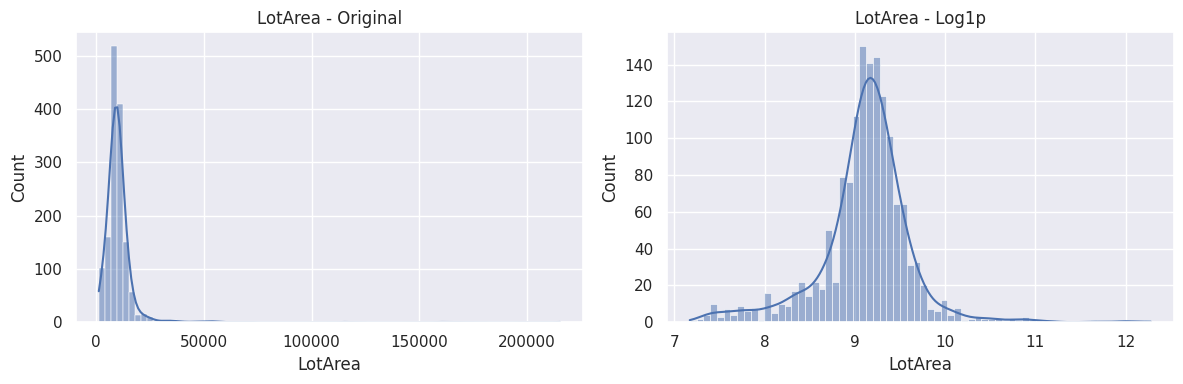

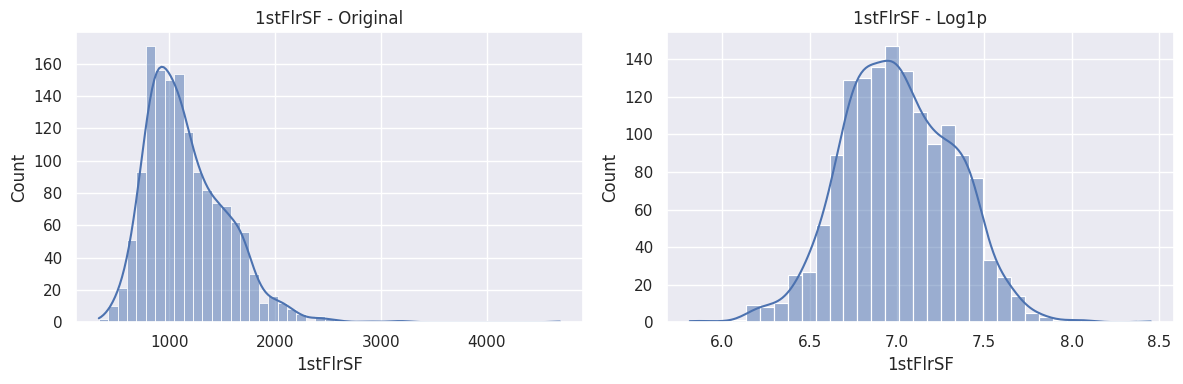

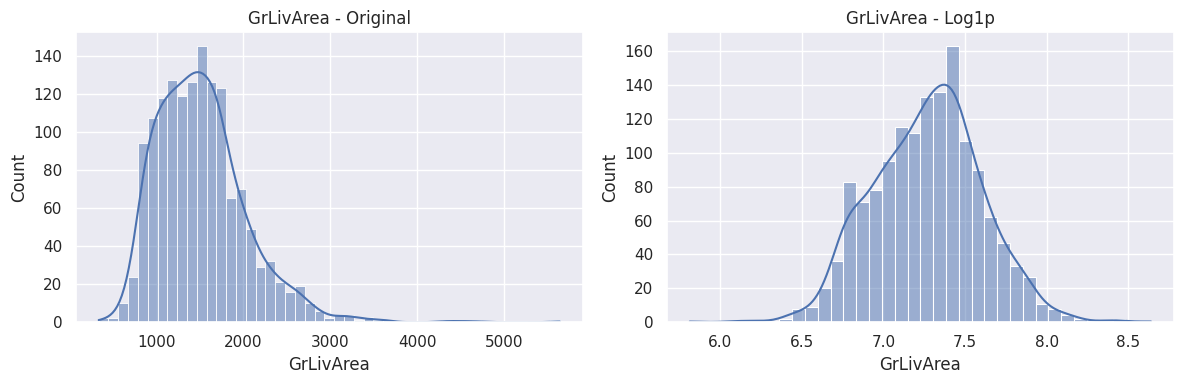

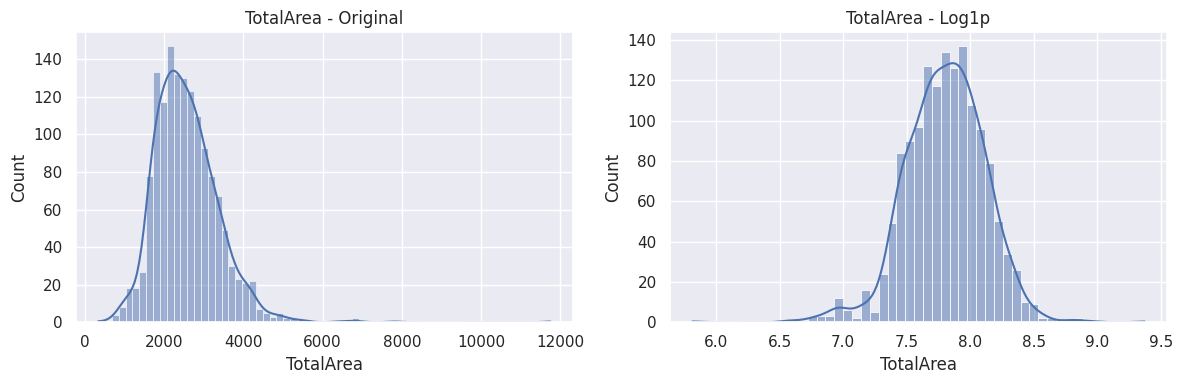

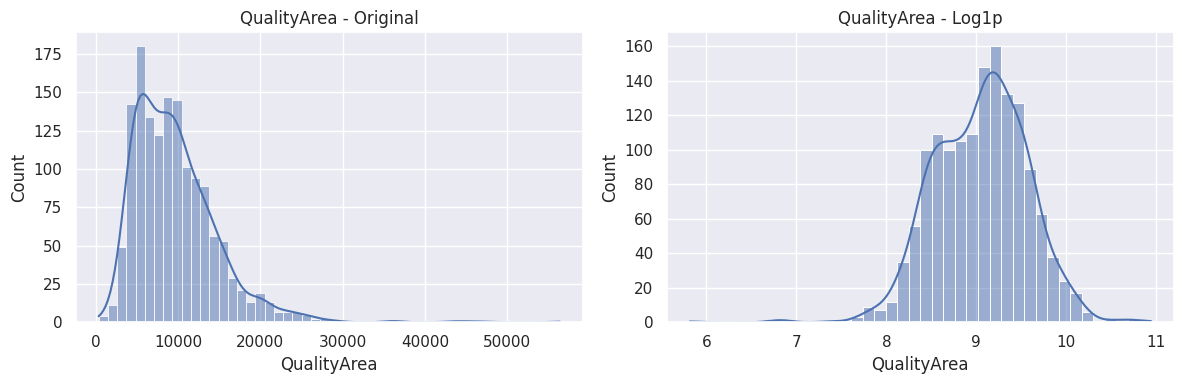

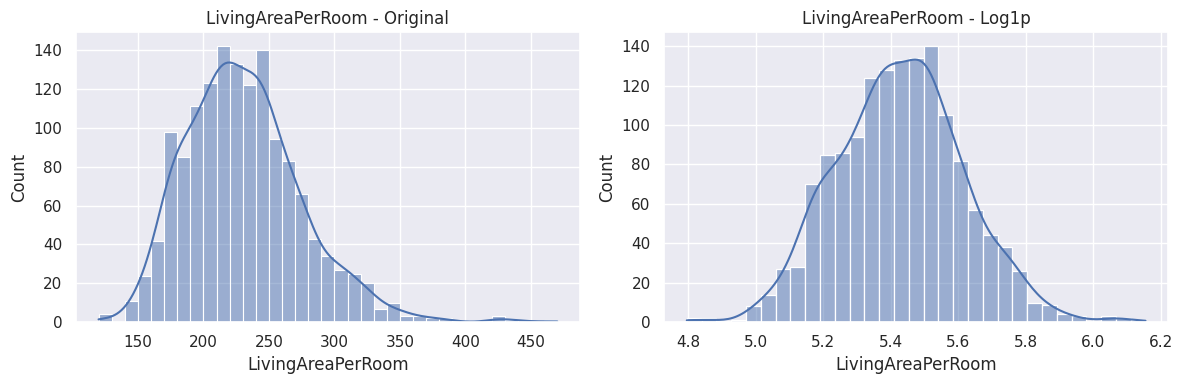

In [7]:
selected_features = [
    # "MSSubClass",
    "LotArea",
    # "MasVnrArea",
    # "BsmtFinSF1",
    # "BsmtFinSF2",
    # "BsmtUnfSF",
    # "TotalBsmtSF",
    "1stFlrSF",
    # "2ndFlrSF",
    # "LowQualFinSF",
    "GrLivArea",
    # "BsmtHalfBath",
    # "KitchenAbvGr",
    # "TotRmsAbvGrd",
    # "WoodDeckSF",
    # "OpenPorchSF",
    # "EnclosedPorch",
    # "3SsnPorch",
    # "ScreenPorch",
    # "PoolArea",
    # "MiscVal",
    # "TotalRooms",
    "TotalArea",
    # "TotalPorchArea",
    "QualityArea",
    "LivingAreaPerRoom",
]

for feature in selected_features:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Original distribution
    sns.histplot(
        X_train[feature],
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"{feature} - Original")

    # Log-transformed distribution
    sns.histplot(
        np.log1p(X_train[feature]),
        kde=True,
        ax=axes[1]
    )
    axes[1].set_title(f"{feature} - Log1p")

    plt.tight_layout()
    plt.show()

## Estratégia de validação

O objetivo final de um modelo de aprendizado de máquina não é apresentar bom desempenho nos dados utilizados durante o treinamento, mas sim generalizar para novas observações não vistas. Avaliar um modelo utilizando os mesmos dados usados para ajustá-lo pode gerar estimativas de desempenho excessivamente otimistas, pois o modelo pode memorizar parcialmente padrões específicos do conjunto de treinamento.

Para obter uma estimativa mais realista do desempenho preditivo, reservamos uma parte dos dados para validação. O modelo é treinado utilizando um subconjunto dos dados e avaliado em outro subconjunto que não participou do treinamento. Isso fornece uma melhor indicação de como o modelo provavelmente se comportará ao realizar previsões para novos imóveis.

Neste projeto, utilizamos validação cruzada *k-fold*. Nessa abordagem, os dados de treinamento são divididos em vários *folds*. O modelo é treinado múltiplas vezes, utilizando a cada iteração um *fold* diferente para validação e os demais para treinamento. A estimativa final de desempenho é obtida calculando a média dos resultados obtidos em todos os *folds*.

A validação cruzada utiliza de maneira mais eficiente os dados disponíveis em comparação com uma única divisão entre treinamento e validação e geralmente fornece uma estimativa mais estável do desempenho do modelo.


In [8]:
# Cross-validation method used for all models
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store the results for each model
results = []

## Baseline 1: Preditor pela média

Antes de avaliar modelos de aprendizado de máquina, é útil estabelecer um modelo de referência (*baseline*) contra o qual abordagens mais sofisticadas possam ser comparadas.

O preditor mais simples possível consiste em atribuir o mesmo preço de venda para todos os imóveis. Uma escolha natural é utilizar o preço médio observado no conjunto de treinamento. Embora esse modelo ignore completamente as características individuais de cada casa, ele fornece um ponto de referência importante: qualquer modelo preditivo deve ser capaz de superar uma estratégia que simplesmente prevê o preço médio para todas as observações.

Ao estabelecer esse *baseline*, podemos quantificar o valor agregado por modelos progressivamente mais complexos e determinar se o esforço adicional de modelagem resulta em melhorias significativas no desempenho preditivo.


In [9]:
mean_price = y_train.mean()

print(f"Mean SalePrice: ${mean_price:,.2f}")

Mean SalePrice: $180,921.20


In [10]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    y_train_fold = y_train.iloc[train_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    prediction = np.full(
        len(y_valid_fold),
        y_train_fold.mean()
    )

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Baseline 1 - Mean Predictor",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})


for k,v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Baseline 1 - Mean Predictor
RMSE Mean : 79244.56167175091
RMSE Std  : 5557.103420903318


## Baseline 2: Modelo baseado em preço por área

Um *baseline* um pouco mais informativo pode ser construído incorporando um dos atributos mais influentes identificados durante a análise exploratória: a área total do imóvel.

Em vez de prever um valor constante para todas as observações, assumimos que os preços dos imóveis variam linearmente com o tamanho da propriedade. Sob essa hipótese, estimamos um preço global por unidade de área utilizando os dados de treinamento e usamos esse valor para gerar as previsões.

### Método

Calculamos o preço médio por unidade de área utilizando o conjunto de treinamento:


In [11]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    # compute price per square foot using ONLY training fold
    avg_price_per_sf = y_train_fold.sum() / X_train_fold["TotalArea"].sum()

    # prediction on validation fold
    prediction = avg_price_per_sf * X_valid_fold["TotalArea"]

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)


results.append({
    "Model": "Baseline 2 - Price per Area",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})


for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Baseline 2 - Price per Area
RMSE Mean : 49131.168566007735
RMSE Std  : 7591.835544518436


### Motivação

A análise exploratória indicou que o tamanho do imóvel é um dos atributos individuais com maior associação ao preço de venda. Este *baseline* avalia quanto poder preditivo pode ser extraído apenas da área do imóvel, sem considerar outras características importantes, como qualidade, localização ou comodidades.

### Visualização

Para compreender melhor essa relação, podemos visualizar:

* Um gráfico de dispersão entre `TotalArea` e `SalePrice`.
* A relação linear ajustada implícita pelo modelo de preço por área.

Essa visualização fornece uma percepção intuitiva de quão bem uma simples relação linear baseada no tamanho do imóvel consegue capturar a variação observada nos preços das casas.


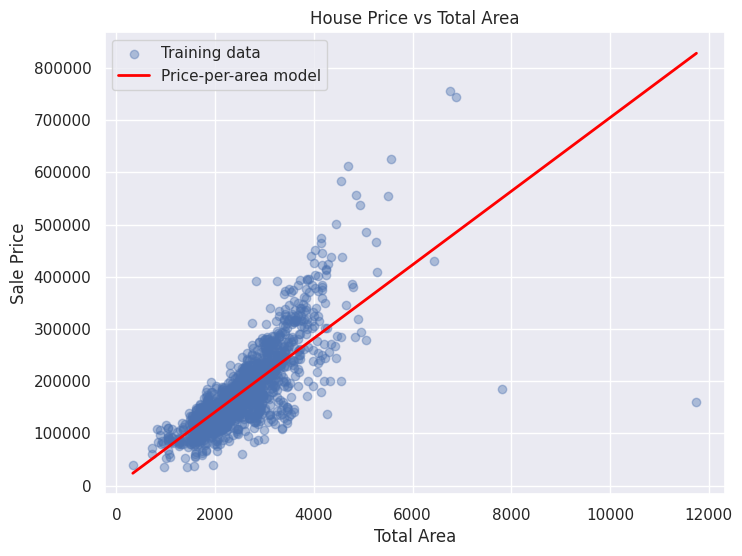

In [12]:
# Price-per-area coefficient (trained only on train set)
avg_price_per_sf = y_train.sum() / X_train["TotalArea"].sum()

# Scatter plot (training data only)
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train["TotalArea"],
    y_train,
    alpha=0.4,
    label="Training data"
)

# Line representing the model
x_vals = np.linspace(
    X_train["TotalArea"].min(),
    X_train["TotalArea"].max(),
    100
)

y_vals = avg_price_per_sf * x_vals

plt.plot(
    x_vals,
    y_vals,
    color="red",
    linewidth=2,
    label="Price-per-area model"
)

plt.title("House Price vs Total Area")
plt.xlabel("Total Area")
plt.ylabel("Sale Price")
plt.legend()
plt.show()

### Discussão

Este modelo assume implicitamente que todos os imóveis possuem o mesmo valor por unidade de área, independentemente de diferenças em qualidade, bairro, estado de conservação, idade ou características adicionais.

Como resultado, ele funciona como um *benchmark* útil, porém limitado, evidenciando a necessidade de modelos mais expressivos capazes de capturar essas fontes adicionais de variação.


## Regressão Linear

Após estabelecermos *baselines* simples, avançamos agora para um modelo padrão de aprendizado de máquina: a regressão linear. Esse modelo amplia o *baseline* baseado em preço por área ao incorporar todos os atributos disponíveis e aprender uma combinação linear ponderada dessas variáveis para prever os preços dos imóveis.

Diferentemente dos *baselines* anteriores, que dependiam de hipóteses simplificadoras, a regressão linear permite que cada atributo contribua individualmente para a previsão, tornando o modelo mais flexível e expressivo, enquanto ainda mantém uma boa interpretabilidade.

### Motivação

A regressão linear funciona como um primeiro modelo natural de aprendizado de máquina. Ela fornece um *baseline* forte e interpretável, permitindo compreender quanto poder preditivo pode ser extraído do conjunto de atributos construídos sob uma hipótese linear.

### Avaliação

O modelo é avaliado utilizando validação cruzada *k-fold* para obter uma estimativa robusta de seu desempenho de generalização. A métrica utilizada é a Raiz do Erro Quadrático Médio (*Root Mean Squared Error* - RMSE), que penaliza erros de previsão grandes e é amplamente utilizada em problemas de regressão como este.

* Treinar o modelo utilizando o conjunto de treinamento.
* Avaliar o desempenho utilizando RMSE de validação cruzada.
* Registrar os resultados para comparação com outros modelos.


In [13]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    prediction = model.predict(X_valid_fold)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Linear Regression",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Linear Regression
RMSE Mean : 42114.85450634172
RMSE Std  : 16150.79821051806


### Efeito das transformações logarítmicas

A regressão linear assume uma relação linear entre os atributos preditores e a variável alvo, além de uma variância aproximadamente constante dos erros. Variáveis com forte assimetria positiva podem tornar essas hipóteses menos adequadas ao dar uma influência desproporcional a observações extremas.

No [notebook anterior](02_feature_engineering.ipynb), identificamos um subconjunto de atributos numéricos com assimetria positiva significativa e os preparamos para transformação logarítmica. Também observamos que a variável alvo (`SalePrice`) apresenta forte assimetria à direita.

Agora investigamos se essas transformações melhoram o desempenho preditivo avaliando duas variantes adicionais do modelo de regressão linear:

* **Log:** utiliza atributos transformados logaritmicamente, mantendo a variável alvo original.
* **Log-Log:** utiliza atributos transformados logaritmicamente e também aplica uma transformação logarítmica à variável alvo.

Ao comparar essas variantes com o modelo original, podemos avaliar o impacto das transformações dos atributos e da variável alvo em um modelo linear simples antes de avançar para algoritmos não lineares mais flexíveis.


### Regressão Linear (Log)

Começamos avaliando o modelo de regressão linear utilizando o conjunto original de atributos. Esse modelo serviu como ponto de referência para comparação com as representações transformadas.

Agora estendemos essa análise avaliando o modelo utilizando o conjunto de atributos transformados logaritmicamente, mantendo a variável alvo inalterada. Esse experimento permite avaliar se a redução da assimetria dos atributos preditores melhora o desempenho de um modelo linear.


In [14]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train_log):

    X_train_fold = X_train_log.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train_log.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    prediction = model.predict(X_valid_fold)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Linear Regression (Log)",
    "RMSE Mean": np.mean(rmse_scores),
    "RMSE Std": np.std(rmse_scores)
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Linear Regression (Log)
RMSE Mean : 45088.79766878106
RMSE Std  : 23461.162281872166


### Regressão Linear (Log-Log)

Por fim, avaliamos o modelo utilizando tanto os atributos transformados logaritmicamente quanto a variável alvo transformada. Como o modelo é treinado no espaço logarítmico, as previsões são convertidas novamente para a escala original antes do cálculo do RMSE, garantindo uma comparação justa com todos os experimentos anteriores.


In [15]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train_log):

    X_train_fold = X_train_log.iloc[train_idx]
    y_train_fold = y_train_log.iloc[train_idx]

    X_valid_fold = X_train_log.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    # Predictions are in log-space
    prediction_log = model.predict(X_valid_fold)

    # Convert predictions back to the original scale
    prediction = np.expm1(prediction_log)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Linear Regression (Log-Log)",
    "RMSE Mean": np.mean(rmse_scores),
    "RMSE Std": np.std(rmse_scores)
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Linear Regression (Log-Log)
RMSE Mean : 30747.156956140272
RMSE Std  : 8602.214831375237


Após avaliar o efeito das transformações dos atributos e da variável alvo em um modelo linear, estendemos agora a análise para algoritmos não lineares mais flexíveis.

Diferentemente da regressão linear, modelos baseados em árvores, como Random Forest e Gradient Boosting, não dependem de hipóteses lineares nem de escalonamento dos atributos. Entretanto, eles ainda podem se beneficiar de transformações que reduzem a assimetria e estabilizam a distribuição dos valores da variável alvo.

Portanto, avaliamos ambos os modelos utilizando as mesmas três representações dos dados:

Atributos originais, atributos transformados logaritmicamente e atributos transformados logaritmicamente combinados com uma variável alvo transformada logaritmicamente.


In [16]:
datasets = {
    "Original": (X_train, y_train),
    "Log": (X_train_log, y_train),
    "Log-Log": (X_train_log, y_train_log)
}

## Random Forest Regressor

Após estabelecermos modelos lineares e *baselines* simples, introduzimos agora uma abordagem de aprendizado de máquina mais flexível: o Random Forest Regressor. Esse modelo pertence à família dos métodos de *ensemble* e é capaz de capturar relações não lineares complexas e interações entre atributos sem a necessidade de especificação manual.

Diferentemente da regressão linear, as florestas aleatórias não assumem uma relação linear entre os atributos e a variável alvo. Em vez disso, elas constroem múltiplas árvores de decisão e agregam suas previsões, resultando em um modelo geralmente mais robusto ao ruído e mais adequado para dados tabulares estruturados, como o conjunto de dados House Prices.

### Motivação

Florestas aleatórias conseguem capturar dependências não lineares e interações entre atributos automaticamente. Isso é particularmente útil neste conjunto de dados, onde variáveis como qualidade, localização, tamanho e comodidades podem interagir de maneiras não aditivas.

### Avaliação

O modelo é avaliado utilizando a mesma estratégia de validação cruzada *k-fold* dos modelos anteriores, garantindo uma comparação justa.

* Treinar o modelo Random Forest em cada *fold* de treinamento.
* Avaliar as previsões utilizando RMSE no *fold* de validação.
* Registrar os resultados para comparação com outros modelos.


In [17]:
for data_name, (X, y) in datasets.items():

    rmse_scores = []

    for train_idx, valid_idx in cv.split(X):

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        model = RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_valid_fold)

        # unify evaluation space
        if data_name == "Log-Log":
            preds = np.expm1(preds)
            y_eval = np.expm1(y_valid_fold)
        else:
            y_eval = y_valid_fold

        rmse = root_mean_squared_error(y_eval, preds)
        rmse_scores.append(rmse)

    results.append({
        "Model": f"Random Forest ({data_name})",
        "RMSE Mean": np.mean(rmse_scores),
        "RMSE Std": np.std(rmse_scores)
    })

    for k, v in results[-1].items():
        print(f"{k:10}: {v}")
    print()

Model     : Random Forest (Original)
RMSE Mean : 30589.05007564849
RMSE Std  : 7942.664892379027

Model     : Random Forest (Log)
RMSE Mean : 30593.233223954412
RMSE Std  : 7925.566053461749

Model     : Random Forest (Log-Log)
RMSE Mean : 29794.82687849537
RMSE Std  : 6738.632614030052



## Gradient Boosting Regressor

Gradient Boosting é uma técnica de aprendizado por *ensemble* que constrói modelos sequencialmente, onde cada novo modelo tenta corrigir os erros cometidos pelos modelos anteriores. Esse processo de refinamento iterativo permite que o modelo capture relações não lineares complexas e interações entre atributos, frequentemente resultando em um forte desempenho preditivo em conjuntos de dados tabulares estruturados.

Diferentemente das Random Forests, que constroem árvores de forma independente e agregam seus resultados, o Gradient Boosting concentra-se na redução gradual dos erros de previsão, tornando-o particularmente eficaz quando são necessárias melhorias mais refinadas.

### Motivação

Gradient Boosting frequentemente apresenta excelente desempenho em conjuntos de dados tabulares estruturados e é uma escolha comum em competições do Kaggle devido à sua alta precisão preditiva e capacidade de modelar relações complexas sem exigir uma extensa engenharia de atributos.

### Avaliação

O modelo é avaliado utilizando a mesma estratégia de validação cruzada *k-fold* aplicada a todos os modelos anteriores, garantindo uma comparação justa entre diferentes abordagens.

* Treinar o modelo Gradient Boosting em cada *fold* de treinamento.
* Avaliar as previsões utilizando RMSE no *fold* de validação.
* Registrar os resultados para comparação com outros modelos.


In [18]:
for data_name, (X, y) in datasets.items():

    rmse_scores = []

    for train_idx, valid_idx in cv.split(X):

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        model = GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_valid_fold)

        # unify evaluation space
        if data_name == "Log-Log":
            preds = np.expm1(preds)
            y_eval = np.expm1(y_valid_fold)
        else:
            y_eval = y_valid_fold

        rmse = root_mean_squared_error(y_eval, preds)
        rmse_scores.append(rmse)

    results.append({
        "Model": f"Gradient Boosting ({data_name})",
        "RMSE Mean": np.mean(rmse_scores),
        "RMSE Std": np.std(rmse_scores)
    })

    for k, v in results[-1].items():
        print(f"{k:10}: {v}")
    print()

Model     : Gradient Boosting (Original)
RMSE Mean : 28296.275062844255
RMSE Std  : 9736.863279304562

Model     : Gradient Boosting (Log)
RMSE Mean : 28277.31652522437
RMSE Std  : 9801.114701967455

Model     : Gradient Boosting (Log-Log)
RMSE Mean : 28035.550594403194
RMSE Std  : 8099.118265230137



## Comparação dos modelos

Após treinar e avaliar todos os *baselines* e modelos de aprendizado de máquina, consolidamos os resultados em uma única tabela de comparação. Isso permite avaliar diretamente o impacto do aumento da complexidade dos modelos no desempenho preditivo.


In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE Mean")
results_df

,Model,RMSE Mean,RMSE Std
10,Gradient Boosting (Log-Log),28035.550594,8099.118265
9,Gradient Boosting (Log),28277.316525,9801.114702
8,Gradient Boosting (Original),28296.275063,9736.863279
7,Random Forest (Log-Log),29794.826878,6738.632614
5,Random Forest (Original),30589.050076,7942.664892
6,Random Forest (Log),30593.233224,7925.566053
4,Linear Regression (Log-Log),30747.156956,8602.214831
2,Linear Regression,42114.854506,16150.798211
3,Linear Regression (Log),45088.797669,23461.162282
1,Baseline 2 - Price per Area,49131.168566,7591.835545


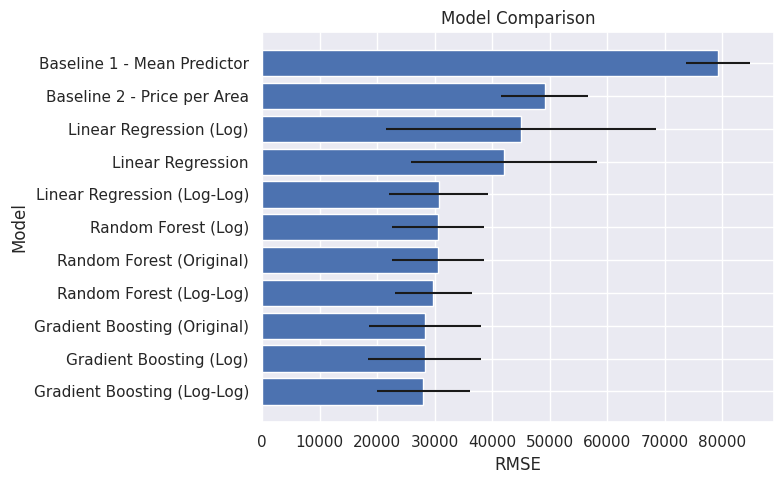

In [20]:
plt.figure(figsize=(8, 5))

plt.barh(
    results_df["Model"],
    results_df["RMSE Mean"],
    xerr=results_df["RMSE Std"]
)

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Model Comparison")

plt.tight_layout()
plt.show()

### Discussão

A comparação destaca como diferentes escolhas de modelagem e transformações dos dados impactam o desempenho preditivo ao longo de todos os experimentos.

O **Preditor pela Média** fornece um *benchmark* ingênuo e representa o desempenho mínimo esperado. O **Modelo baseado em Preço por Área** introduz uma hipótese simples baseada em conhecimento de domínio e melhora esse *baseline* ao incorporar um dos atributos individuais mais fortes para explicar os preços dos imóveis.

O modelo de **Regressão Linear** utiliza todo o conjunto de atributos construídos sob uma hipótese linear. Seu erro relativamente maior indica que apenas relações lineares não são suficientes para capturar a complexidade dos dados.

Métodos de *ensemble* baseados em árvores apresentam melhorias significativas no desempenho preditivo:

* **Random Forest** reduz o erro ao capturar relações não lineares e interações entre atributos. Seu desempenho é estável, mas apresenta sensibilidade limitada às transformações de entrada.
* **Gradient Boosting** alcança os melhores resultados gerais, superando todos os outros modelos ao corrigir sequencialmente os erros residuais e otimizar a precisão preditiva.

Um resultado adicional importante é o efeito das transformações logarítmicas. Embora as transformações dos atributos tenham impacto mínimo nos modelos baseados em árvores, a aplicação de uma transformação logarítmica na variável alvo melhora consistentemente o desempenho, especialmente no Gradient Boosting. Isso sugere que reduzir a assimetria da variável alvo contribui mais para a eficácia do modelo do que transformar os atributos de entrada.

De modo geral, os resultados mostram que a complexidade dos modelos e os mecanismos de correção de erros (como no *boosting*) são mais importantes do que o escalonamento dos atributos para este conjunto de dados, embora a transformação da variável alvo forneça um ganho pequeno, porém consistente.

### Seleção do modelo

Com base no desempenho obtido pela validação cruzada, o modelo com menor RMSE médio é selecionado como modelo final. Esse modelo será treinado novamente utilizando todo o conjunto de treinamento e utilizado para gerar previsões para o conjunto de teste do Kaggle.


## Treinamento do modelo final

Após comparar todos os modelos utilizando validação cruzada, selecionamos a abordagem com melhor desempenho com base no menor RMSE médio. Esse modelo é então treinado novamente utilizando todo o conjunto de dados de treinamento, a fim de maximizar a quantidade de informação disponível durante o aprendizado.

Diferentemente da validação cruzada, na qual o modelo é treinado em subconjuntos dos dados, o modelo final é ajustado utilizando todas as observações rotuladas disponíveis. Isso garante que nenhuma informação do conjunto de treinamento seja desperdiçada antes da geração das previsões para o conjunto de teste.

O modelo treinado é então utilizado para produzir previsões para o conjunto de teste do Kaggle, que serão enviadas para avaliação no *leaderboard* da competição.


In [21]:
best_row = results_df.sort_values("RMSE Mean").iloc[0]
best_label = best_row["Model"]

print("Best model:", best_label)

import re
match = re.match(r"(.*)\s\((.*)\)", best_label)
model_name = match.group(1)
data_name = match.group(2)

model_map = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

datasets = {
    "Original": (X_train, y_train),
    "Log": (X_train_log, y_train),
    "Log-Log": (X_train_log, y_train_log)
}

X_best, y_best = datasets[data_name]
best_model = model_map[model_name]

best_model.fit(X_best, y_best)

test_X = {
    "Original": X_test,
    "Log": X_test_log,
    "Log-Log": X_test_log
}[data_name]

test_preds = best_model.predict(test_X)

if data_name == "Log-Log":
    test_preds = np.expm1(test_preds)

Best model: Gradient Boosting (Log-Log)


## Diagnóstico do modelo

Após selecionar e treinar o modelo final, é útil inspecionar visualmente suas previsões. Embora as métricas de validação cruzada forneçam uma medida quantitativa do desempenho, gráficos de diagnóstico podem revelar padrões sistemáticos que nem sempre são evidentes apenas a partir de estatísticas resumidas.

Em particular, comparamos os preços de venda previstos e reais para avaliar o quão próximo o modelo consegue reproduzir os valores observados. Também analisamos os resíduos para identificar possíveis vieses, como subestimação ou superestimação sistemática em determinadas faixas de preço.

Esses diagnósticos fornecem uma confiança adicional de que o modelo está se comportando conforme esperado antes da geração das previsões para o conjunto de teste do Kaggle.


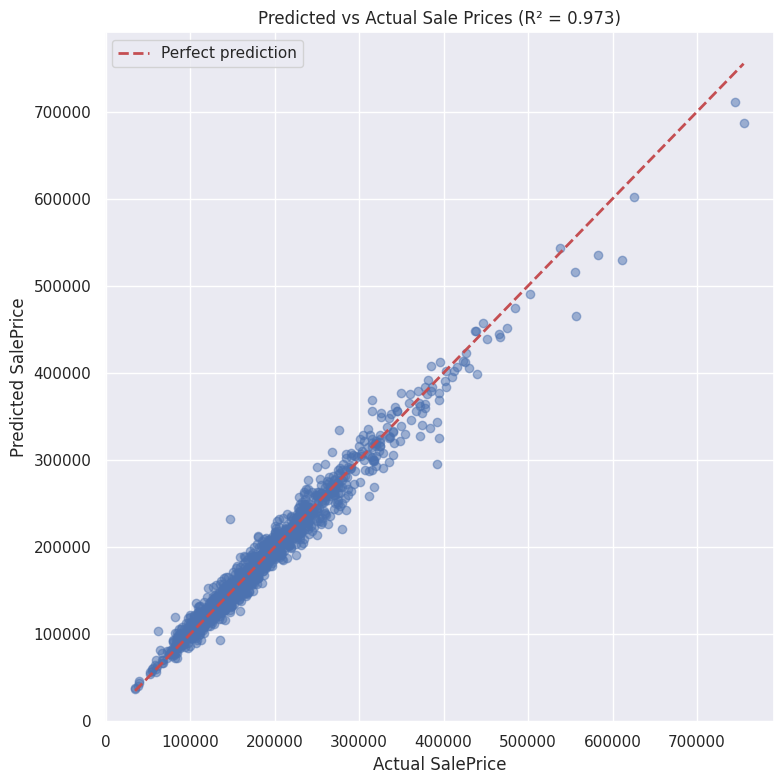

In [22]:
# Retrieve correct training set for the best model
X_best, y_best = datasets[data_name]

# Fit final model on full training data
best_model.fit(X_best, y_best)

# Predictions on training data
train_preds = best_model.predict(X_best)

# --- Handle inverse transform if needed ---
if data_name == "Log-Log":
    train_preds = np.expm1(train_preds)
    y_plot = np.expm1(y_best)
else:
    y_plot = y_best

# --- Predicted vs Actual plot ---
plt.figure(figsize=(8, 8))

plt.scatter(
    y_plot,
    train_preds,
    alpha=0.5
)

# Perfect prediction line
min_val = min(y_plot.min(), train_preds.min())
max_val = max(y_plot.max(), train_preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

r2 = r2_score(y_plot, train_preds)
plt.title(f"Predicted vs Actual Sale Prices (R² = {r2:.3f})")

plt.legend()
plt.tight_layout()
plt.show()

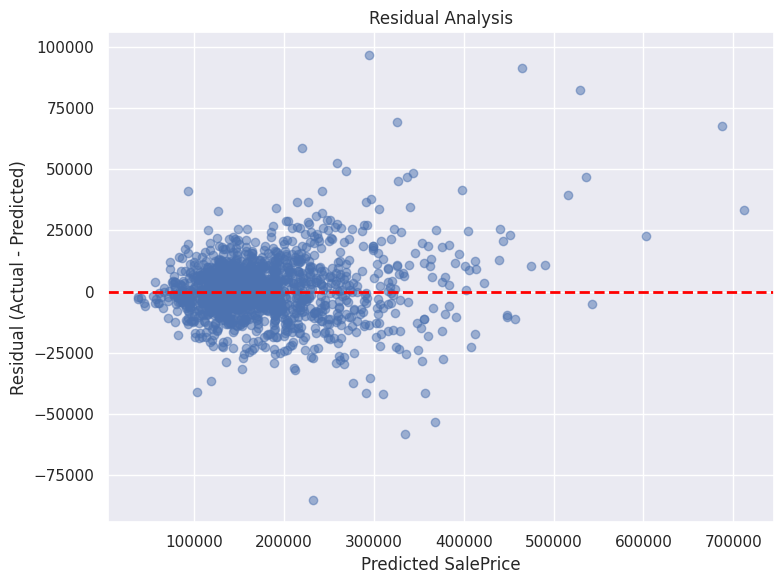

In [23]:
# Ensure correct dataset alignment
X_best, y_best = datasets[data_name]

# Fit model on correct representation
best_model.fit(X_best, y_best)

# Predictions
train_preds = best_model.predict(X_best)

# Unify space for plotting
if data_name == "Log-Log":
    train_preds = np.expm1(train_preds)
    y_plot = np.expm1(y_best)
else:
    y_plot = y_best

# Residuals
residuals = y_plot - train_preds

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    train_preds,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## Importância dos atributos

Para compreender melhor o comportamento do modelo Gradient Boosting selecionado, analisamos os valores de importância dos atributos.

A importância dos atributos quantifica quanto cada variável contribui para a redução do erro de previsão ao longo do conjunto de árvores de decisão que compõem o *ensemble*.

Embora esses valores não devam ser interpretados como relações causais, eles fornecem informações úteis sobre quais características dos imóveis foram mais influentes na determinação dos preços das casas.


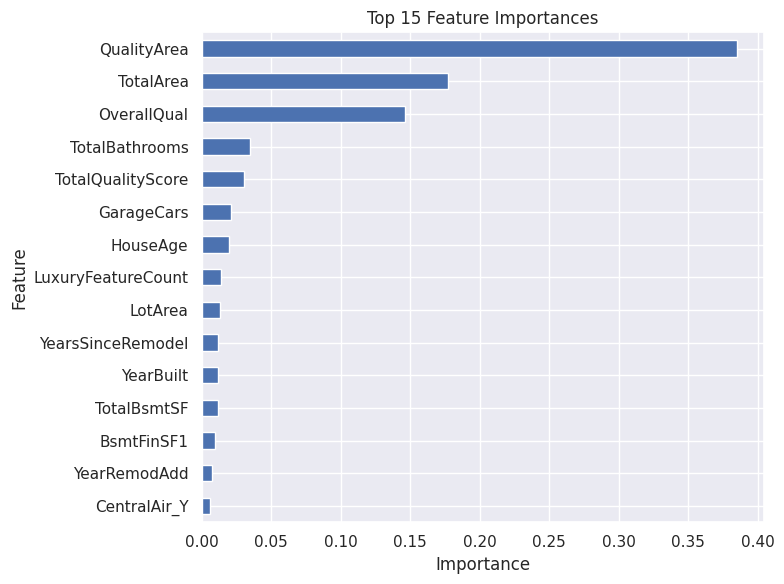

In [24]:
# Ensure we use the correct dataset used in training
X_best, y_best = datasets[data_name]

# Refit model (or ensure it's already fitted consistently)
best_model.fit(X_best, y_best)

# Check if model supports feature importance
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X_best.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))

    feature_importance.head(15).sort_values().plot(
        kind="barh"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Feature Importances")

    plt.tight_layout()
    plt.show()

else:
    print(f"{type(best_model).__name__} does not support feature_importances_.")

Vários atributos construídos aparecem entre os preditores mais importantes, sugerindo que o processo de engenharia de atributos conseguiu capturar informações além das variáveis originais do conjunto de dados.

Em particular, atributos relacionados à qualidade geral, área habitável e tamanho ajustado pela qualidade contribuem significativamente para o poder preditivo do modelo. Isso está alinhado com os padrões observados durante a análise exploratória, na qual o tamanho do imóvel e a qualidade da construção apresentaram fortes relações com o preço de venda.


## Criar arquivo de submissão

Com o modelo final treinado utilizando todo o conjunto de dados de treinamento, geramos agora as previsões para o conjunto de teste do Kaggle. Essas previsões representam as estimativas do modelo para os preços de venda de cada imóvel não observado durante o treinamento.

O arquivo de submissão deve seguir o formato exigido pela competição, contendo a coluna `Id` e os respectivos valores previstos de `SalePrice`.


In [25]:
# 1. Select correct test matrix
if data_name == "Original":
    X_test_used = X_test

elif data_name == "Log":
    X_test_used = X_test_log

elif data_name == "Log-Log":
    X_test_used = X_test_log

# 2. Predict on correct space
test_preds = best_model.predict(X_test_used)

# 3. Inverse transform ONLY if needed
if data_name == "Log-Log":
    test_preds = np.expm1(test_preds)

# 4. Safety checks (important)
print("Prediction range:")
print("min:", np.min(test_preds))
print("max:", np.max(test_preds))

assert np.isfinite(test_preds).all(), "ERROR: NaN or Inf detected in predictions"

# 5. Build submission
submission = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": test_preds
})

# 6. Save file
submission.to_csv("../data/processed/submission.csv", index=False)

# 7. Preview
submission.reset_index(drop=True)

Prediction range:
min: 38820.16486249425
max: 536818.182029515


,Id,SalePrice
0,1461,122931.916693
1,1462,156930.494322
2,1463,178714.875635
3,1464,191414.553367
4,1465,194186.336990
...,...,...
1454,2915,88838.233381
1455,2916,79755.345632
1456,2917,161538.840630
1457,2918,120414.333650


## Resumo final

Neste notebook, concluímos o pipeline completo de modelagem para o problema de previsão de preços de imóveis do conjunto House Prices.

Começamos estabelecendo modelos de *baseline* simples, incluindo um preditor constante baseado na média e uma heurística baseada em preço por área. Esses modelos forneceram pontos de referência para avaliar o benefício de abordagens mais complexas.

Em seguida, treinamos e avaliamos diversos modelos de aprendizado de máquina, incluindo Regressão Linear, Random Forest e Gradient Boosting, utilizando uma estratégia consistente de validação cruzada baseada em RMSE. Isso permitiu uma comparação justa entre todos os métodos.

Os resultados mostraram que o aumento da complexidade dos modelos geralmente melhorou o desempenho preditivo, com métodos de *ensemble* superando abordagens lineares mais simples.

Por fim, selecionamos o modelo com melhor desempenho, realizamos um novo treinamento utilizando todo o conjunto de dados de treinamento e geramos previsões para o conjunto de teste do Kaggle. Essas previsões foram salvas no formato de submissão exigido pela competição.

Isso conclui o pipeline de modelagem. Melhorias futuras poderiam incluir ajuste de hiperparâmetros, seleção de atributos, combinação de modelos (*stacking*) ou o uso de frameworks mais avançados de *gradient boosting*, como XGBoost, LightGBM ou CatBoost.
